In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, lfilter_zi

In [7]:
plt.rcParams.update({
    # Figure & Resolution
    'figure.figsize': (3, 1.5),      # Standard rectangular size
    'figure.dpi': 100,             # High resolution for saving
    'savefig.dpi': 300,            # High resolution for exported images
    'savefig.bbox': 'tight',       # Removes unnecessary white space around the plot
    
    # Fonts & Text
    'font.family': 'sans-serif',   # Use serif for traditional journals, sans-serif for modern
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,               # Base font size
    'axes.titlesize': 10,          # Title size
    'axes.labelsize': 10,          # X and Y label size
    'xtick.labelsize': 10,         # Tick label size
    'ytick.labelsize': 10,         # Tick label size
    'legend.fontsize': 10,         # Legend text size
    
    # Axes & Spines (The "Clean" Look)
    'axes.spines.top': False,      # Remove top bounding box line
    'axes.spines.right': False,    # Remove right bounding box line
    'axes.linewidth': 1.1,         # Slightly thicker axes lines
    'axes.grid': False,            # Default to no grid (turn on manually if needed)
    
    # Ticks
    'xtick.direction': 'in',       # Ticks point inward
    'ytick.direction': 'in',       # Ticks point inward
    'xtick.major.size': 6,         # Major tick length
    'xtick.major.width': 1.2,      # Major tick thickness
    'ytick.major.size': 6,         # Major tick length
    'ytick.major.width': 1.2,      # Major tick thickness
    
    # Lines & Markers
    'lines.linewidth': 1.5,        # Thicker lines for visibility
    'lines.markersize': 4,         # Standard marker size
    
    # Legend
    'legend.frameon': False,       # Remove the box around the legend
    'legend.loc': 'best'           # Automatically place legend out of the way
})

x type: float64 x2 type: complex128


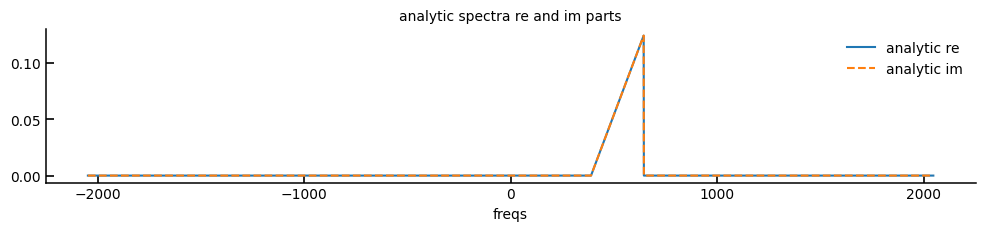

In [8]:
#generate some spectra

Norig = 256
extend = 16
N = Norig * extend
X = np.zeros(N//2+1,dtype='complex128')
Xc = np.zeros(N,dtype='complex128') #analytic
k0 = 32 * extend + 5 #Will not be at the center of any channel of smaller FFT sizes. 
dk = 8 * extend
triangle = np.arange(0,2*dk)/N + 1j*np.arange(0,2*dk)/N #triangular real and imag parts (not-symmetric)

X[k0-dk:k0+dk]=triangle 
x=np.fft.irfft(X) #note irfft. -ve freqs will be conjugate of +ve freqs.  generates a real signal


Xc[k0-dk:k0+dk]=2*triangle # ignore -ve freqs and double +ve freqs
x2=np.fft.ifft(Xc) #note ifft.  generates a complex signal

freqs = np.fft.fftshift(np.fft.fftfreq(N))*N
# print(freqs)
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x2).real),label='analytic re' )
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x2).imag),label='analytic im' ,ls='dashed')
plt.xlabel("freqs")
plt.title("analytic spectra re and im parts")
plt.legend()


print("x type:", x.dtype, "x2 type:", x2.dtype)

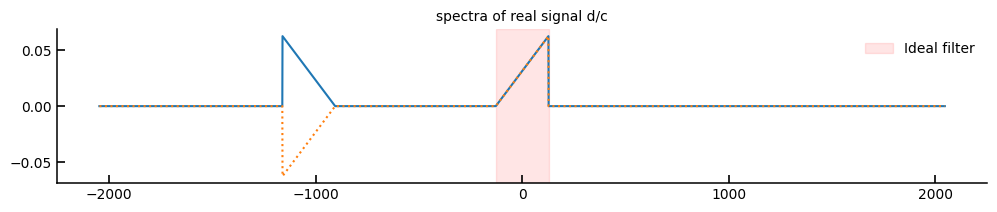

In [9]:
x_rotated = x*np.exp(-2j*np.pi*np.arange(N)*k0/N)
plt.title("spectra of real signal d/c")
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x_rotated).real))
plt.plot(freqs,np.fft.fftshift(np.fft.fft(x_rotated).imag),ls='dotted')
plt.axvspan(-dk,dk,color='red',alpha=0.1,label='Ideal filter')
plt.legend()

We want to snip the highlighted part of the spectrum. Here, We have access to the entire big block of data here where the simulated center frequency is an integer. If we wanted, we can just extract the part we want from the array. 

In real-life, that's almost never the case. Imagine filtering data continuously on a car FM radio. We're not going to take one gigantic 10-hour long FFT. Instead, we must think about how to filter continuously in time domain.

crucial difference is that we have all the data available.In reality, data often comes in real time. Data block convention is linear in time. Thus we gotta fix our filter to be linear in time. 

FFT convention is circular buffer.

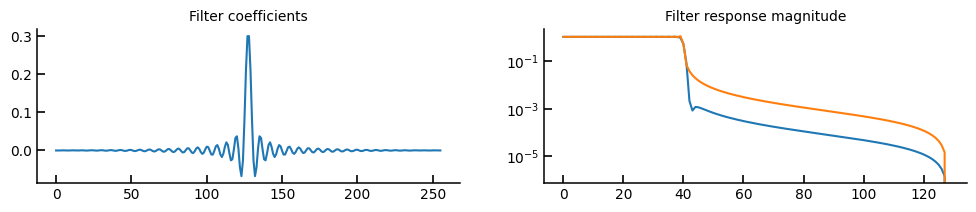

In [10]:
#first lets design a filter
h = firwin(Norig, cutoff=0.3125, window='hamming')
fig=plt.gcf()
fig.set_size_inches(12,2)
plt.subplot(121)
plt.title("Filter coefficients")
plt.plot(h)

plt.subplot(122)
plt.title("Filter response magnitude")
plt.semilogy(np.abs(np.fft.rfft(h)))
plt.plot(np.abs(np.fft.rfft(firwin(Norig, cutoff=0.3125, window=('kaiser',1)))))


Scipy `firwin` returns causal filters. This is what we use in real-life because a filter never has access to future data.

Usual filtering equation goes

$y[n] = \sum_m x[n - m] h[m]$

Our sim data was generated using an FFT and is therefore sitting in a circular buffer. Let us roll it so that left-to-right is a linear arrow in time. Then we'll filter it in chunks of 256.

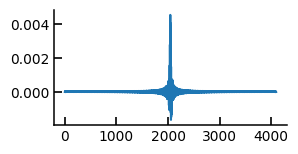

In [41]:
x_rotated_linear = np.fft.fftshift(x_rotated)
plt.plot(x_rotated_linear)

In [45]:
z

256

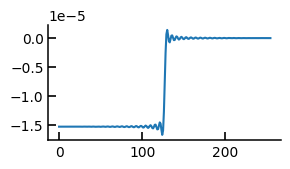

In [47]:
taps = firwin(Norig, cutoff=0.35)
output_stream = np.zeros(N, dtype='complex128')

zi = lfilter_zi(taps, 1.0) * x_rotated_linear[0]
plt.plot(zi)
num_blocks = N//Norig
for i in range(N//Norig):
    # Grab the current block
    start_idx = i * Norig
    end_idx = start_idx + Norig
    block = x_rotated_linear[start_idx:end_idx]
    
    # Filter the block. 
    # Pass in the state from the previous iteration (zi).
    # It returns the filtered data AND the new state (zf).
    filtered_block, zf = lfilter(taps, 1.0, block, zi=zi)
    
    # Store the output
    output_stream[start_idx:end_idx] = filtered_block
    
    # IMPORTANT: Update zi for the next block
    zi = zf

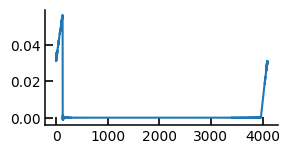

In [44]:
delay = (Norig - 1) // 2

# 2. Shift the time-domain signal backwards to completely undo the delay
output_aligned = np.roll(output_stream, -delay)

# 3. Rewrap back to circular FFT format 
# (Always use ifftshift to reverse fftshift for safety with odd/even lengths)
x_rot_filt = np.fft.ifftshift(output_aligned)
# x_rot_filt = np.fft.fftshift(output_stream)
# x_rot_filt = output_stream
# plt.plot(np.fft.fftshift(np.abs(np.fft.fft(x_rot_filt))))
plt.plot(np.fft.fft(x_rot_filt).imag)
# plt.xlim(0,50)

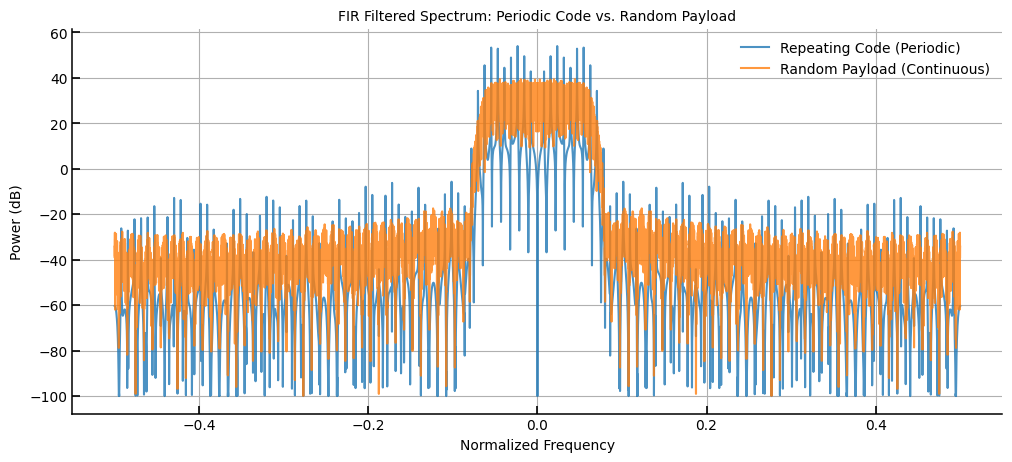

In [27]:
from scipy.signal import upfirdn, firwin

sps = 8
num_taps = 101
cutoff_freq = 1.0 / sps
pulse_shape_taps = firwin(num_taps, cutoff_freq, window='hamming')

# --- 1. The Deterministic Repeating Code ---
# A short 16-bit code repeated over and over
short_code = np.array([1, -1, 1, 1, -1, 1, -1, -1, 1, 1, 1, -1, -1, -1, 1, -1])
repeating_symbols = np.tile(short_code, 100) # Repeat 100 times
repeating_baseband = upfirdn(pulse_shape_taps, repeating_symbols, up=sps)

# --- 2. The Random Payload ---
# 1600 completely random bits
random_symbols = np.random.choice([-1, 1], size=1600)
random_baseband = upfirdn(pulse_shape_taps, random_symbols, up=sps)

# --- 3. Plot the Spectra ---
plt.figure(figsize=(12, 5))

freqs = np.fft.fftshift(np.fft.fftfreq(len(repeating_baseband)))

# Spectrum of the repeating code (The Comb)
rep_spectrum = 10*np.log10(np.fft.fftshift(np.abs(np.fft.fft(repeating_baseband))**2) + 1e-10)
plt.plot(freqs, rep_spectrum, label='Repeating Code (Periodic)', alpha=0.8)

# Spectrum of the random data (The Filled Bandwidth)
rand_spectrum = 10*np.log10(np.fft.fftshift(np.abs(np.fft.fft(random_baseband))**2) + 1e-10)
plt.plot(freqs, rand_spectrum, label='Random Payload (Continuous)', alpha=0.8)

plt.title("FIR Filtered Spectrum: Periodic Code vs. Random Payload")
plt.xlabel("Normalized Frequency")
plt.ylabel("Power (dB)")
plt.legend()
plt.grid(True)
plt.show()